# frag_xvenue — Herfindahl, crash share, concordance

Tee & Ting §4.1 / Table IX on **HL + Deribit + Kraken**. Severity-gated SSM (z*=6, ≥5 bps) so micro-outliers do not dominate.


In [1]:
from pathlib import Path
import json
OUT = Path('../../out/frag_xvenue').resolve()
s = json.loads((OUT / 'frag_summary.json').read_text())
p = s['pooled']
print('H_v_mean', p.get('H_v_mean'), 'H_v_pooled', p.get('H_v_pooled'))
print('vol_shares', p.get('vol_shares_pooled'))
print('crash_5bps', p['crash_shares_pooled']['ssm_5bps'])
print('concord_jac_5s', p.get('concord_jaccard_5s_mean'))
print('thin', p.get('thin_venue_pooled', {}).get('ssm_5bps'))
print('placebo_p', p.get('placebo_p_ge_obs_mean'))
print('epps day/crash@1s', p.get('epps_day_corr_1s_mean'), p.get('epps_crash_corr_1s_mean'))



H_v_mean 0.48173741550321825 H_v_pooled 0.48950294302152425
vol_shares {'hyperliquid': 0.04048730831061115, 'deribit': 0.3624289872901404, 'kraken': 0.5970837043992484}
crash_5bps {'counts': {'hyperliquid': 486, 'deribit': 60, 'kraken': 43}, 'shares': {'hyperliquid': 0.8251273344651953, 'deribit': 0.10186757215619695, 'kraken': 0.0730050933786078}, 'total': 589}
concord_jac_5s {'hyperliquid_deribit': 0.0, 'hyperliquid_kraken': 0.0, 'deribit_kraken': 0.1255426391790028}
thin {'rows': [{'venue': 'hyperliquid', 'vol_share': 0.04048730831061115, 'crash_share': 0.8251273344651953, 'excess': 0.7846400261545841}, {'venue': 'deribit', 'vol_share': 0.3624289872901404, 'crash_share': 0.10186757215619695, 'excess': -0.26056141513394343}, {'venue': 'kraken', 'vol_share': 0.5970837043992484, 'crash_share': 0.0730050933786078, 'excess': -0.5240786110206406}], 'spearman_volshare_vs_excess': -1.0, 'thin_venue': 'hyperliquid', 'thin_excess': 0.7846400261545841, 'hypothesis': 'thin venues have crash_sha

## Volume Herfindahl + shares


### `figs/fig_herfindahl_shares.png`


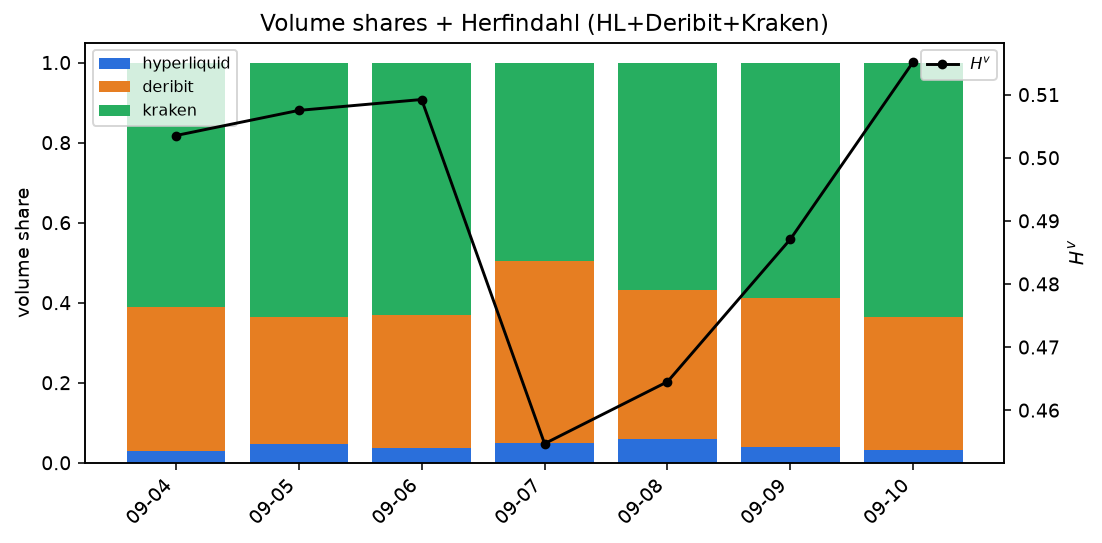

In [ ]:
from IPython.display import Image; Image('../../out/frag_xvenue/figs/fig_herfindahl_shares.png')


### `figs/fig_crash_vs_vol_share.png`


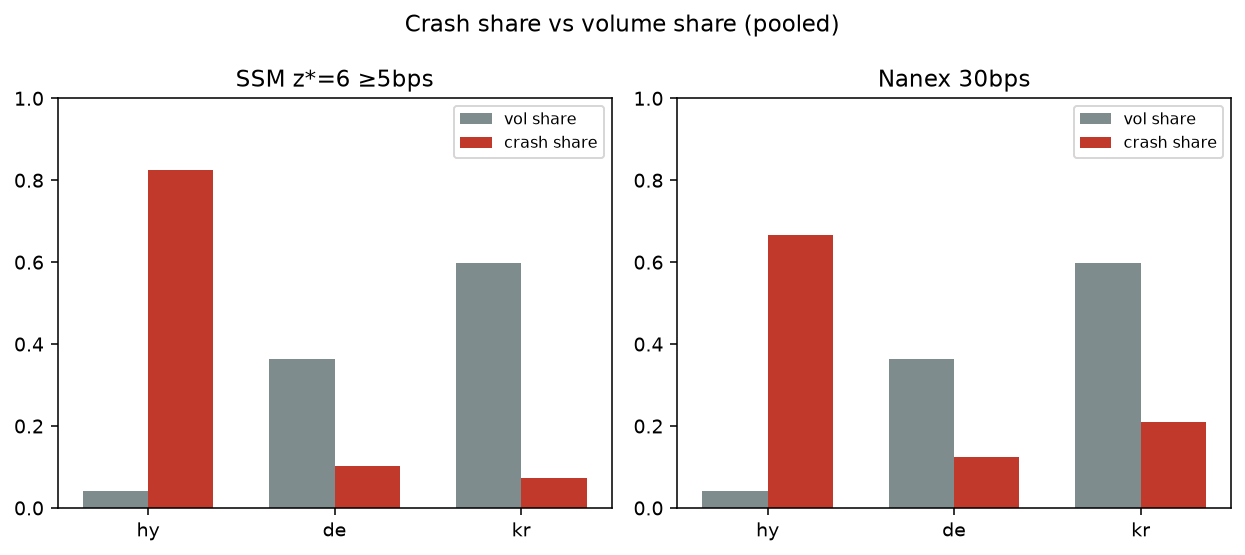

In [ ]:
from IPython.display import Image; Image('../../out/frag_xvenue/figs/fig_crash_vs_vol_share.png')


### `figs/fig_concordance_slack.png`


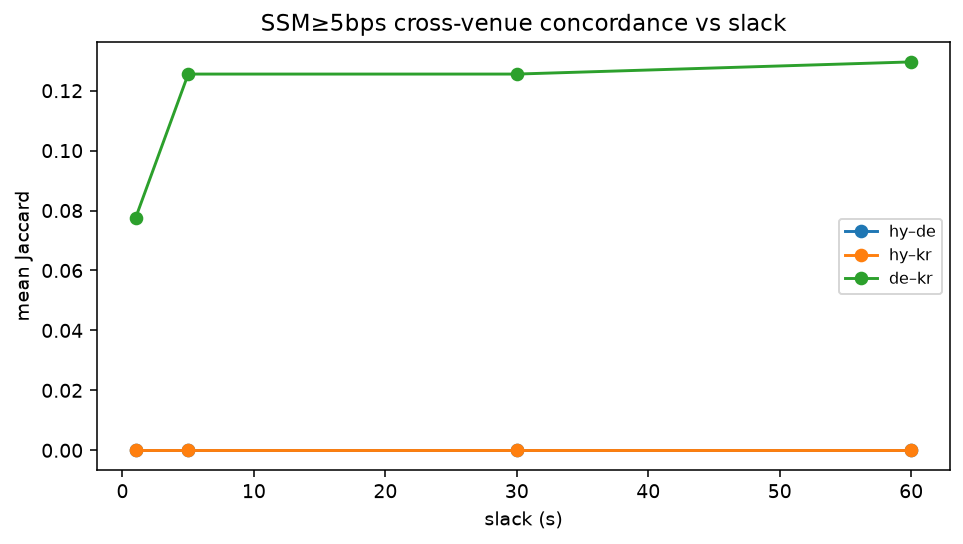

In [ ]:
from IPython.display import Image; Image('../../out/frag_xvenue/figs/fig_concordance_slack.png')


### `figs/fig_epps_day_vs_crash.png`


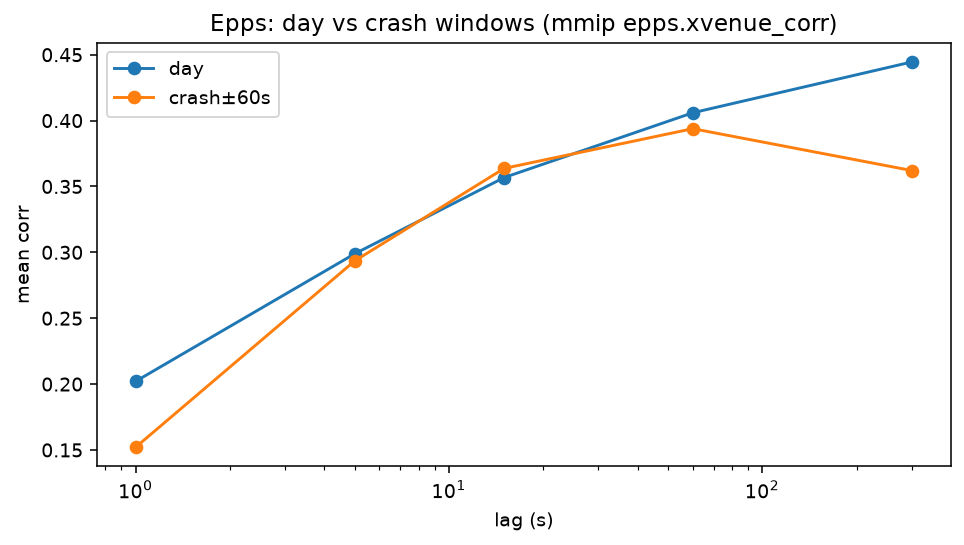

In [ ]:
from IPython.display import Image; Image('../../out/frag_xvenue/figs/fig_epps_day_vs_crash.png')


### `figs/fig_severity_gate.png`


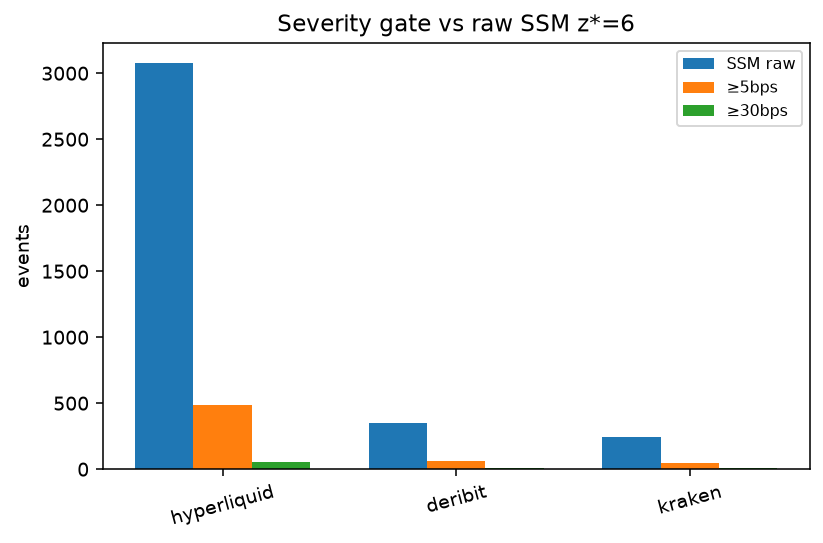

In [ ]:
from IPython.display import Image; Image('../../out/frag_xvenue/figs/fig_severity_gate.png')


## Signal board

| ID | Desk label | Decision |
|----|------------|----------|
| `frag.volume_herfindahl_3venue` | Frag / SOR capacity monitor | see CANDIDATES |
| `frag.crash_venue_share` | Risk: where crashes print | Promote (gated) |
| `frag.thin_venue_crash_excess` | Thin-venue risk flag | see CANDIDATES |
| `frag.xvenue_crash_concord` | Sync / contagion monitor | see CANDIDATES |
| `frag.crossed_nbbo_crashwin` | Exec throttle | Hold (TOB) |

**Cross-links:** mmip `frag.crossed_nbbo`, `epps.xvenue_corr`; empirical_mm `disc.jump_sign_concord`.

